In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv(r"D:\electricity_bill_dataset.csv")
df.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8,3806.4
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7,3203.2
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2,4370.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4


In [30]:
#replacing cities with my Country's cities 
city_company_map = {
    "Hyderabad":   ("Hyderabad",       "Hyderabad Electric Supply Company (HESCO)"),
    "Navi Mumbai": ("Karachi",         "K-Electric (KE)"),
    "Ratnagiri":   ("Gwadar",          "Quetta Electric Supply Company (QESCO)"),
    "Faridabad":   ("Rawalpindi",      "Islamabad Electric Supply Company (IESCO)"),
    "Gurgaon":     ("Islamabad",       "Islamabad Electric Supply Company (IESCO)"),
    "Ahmedabad":   ("Faisalabad",      "Faisalabad Electric Supply Company (FESCO)"),
    "New Delhi":   ("Lahore",          "Lahore Electric Supply Company (LESCO)"),
    "Mumbai":      ("Sialkot",         "Gujranwala Electric Power Company (GEPCO)"),
    "Chennai":     ("Multan",          "Multan Electric Power Company (MEPCO)"),
    "Dahej":       ("Sukkur",          "Sukkur Electric Power Company (SEPCO)"),
    "Nagpur":      ("Quetta",          "Quetta Electric Supply Company (QESCO)"),
    "Noida":       ("Peshawar",        "Peshawar Electric Supply Company (PESCO)"),
    "Pune":        ("Bahawalpur",      "Multan Electric Power Company (MEPCO)"),
    "Shimla":      ("Abbottabad",      "Peshawar Electric Supply Company (PESCO)"),
    "Kolkata":     ("Mirpur (AJK)",    "Islamabad Electric Supply Company (IESCO)"),
    "Vadodara":    ("Sargodha",        "Faisalabad Electric Supply Company (FESCO)"),
}
df["Company"] = df["City"].map(lambda c: city_company_map[c][1])
df["City"] = df["City"].map(lambda c: city_company_map[c][0])

KeyError: 'Sargodha'

In [34]:

# Save the updated dataset 
df.to_csv("electricity_bill_dataset_pakistan.csv", index=False)
df.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Hyderabad Electric Supply Company (HESCO),384,8.4,3225.6
1,19,22.0,2.0,3.0,1.0,0,5,Sargodha,Faisalabad Electric Supply Company (FESCO),488,7.8,3806.4
2,7,20.0,2.0,6.0,7.0,0,7,Abbottabad,Peshawar Electric Supply Company (PESCO),416,7.7,3203.2
3,7,22.0,3.0,21.0,1.0,0,6,Sialkot,Gujranwala Electric Power Company (GEPCO),475,9.2,4370.0
4,11,23.0,2.0,11.0,1.0,0,2,Sialkot,Gujranwala Electric Power Company (GEPCO),457,9.2,4204.4


In [36]:
RATES = {
    "slabs": {
        "lifeline": [
            {"upto": 50,  "rate": 3.95},
            {"upto": 100, "rate": 7.74},
        ],
        "protected": [
            {"upto": 100, "rate": 10.54},
            {"upto": 200, "rate": 13.01},
        ],
        "unprotected": [
            {"upto": 100,        "rate": 22.44},
            {"upto": 200,        "rate": 28.91},
            {"upto": 300,        "rate": 33.10},
            {"upto": 400,        "rate": 37.99},
            {"upto": 500,        "rate": 40.22},
            {"upto": 600,        "rate": 41.62},
            {"upto": 700,        "rate": 42.76},
            {"upto": float("inf"), "rate": 47.69},
        ],
    },
    "fixed_charge": {          
        "single": 75,
        "three": 150,
    },
    "gst_percent": 17,               
    "electricity_duty_percent": 1.5, 
    "tv_fee": 35,                   
    "non_filer_tax": {
        "threshold_bill": 25000,   
        "rate_percent": 7.5,       
    },
}
RATES["fpa_per_unit"] = 2.50

In [38]:
def calculate_pakistani_bill(units, sanctioned_load_kw=1, category="unprotected"):
    slabs = RATES["slabs"].get(category, RATES["slabs"]["unprotected"])

    energy_charge = 0
    remaining = units
    prev_upto = 0
    for slab in slabs:
        slab_units = min(remaining, slab["upto"] - prev_upto)
        if slab_units <= 0:
            break
        energy_charge += slab_units * slab["rate"]
        remaining -= slab_units
        prev_upto = slab["upto"]
        if remaining <= 0:
            break

    fixed_charge = RATES["fixed_charge"]["three"] if sanctioned_load_kw > 5 else RATES["fixed_charge"]["single"]
    fpa_amount = units * RATES["fpa_per_unit"]
    electricity_duty = energy_charge * RATES["electricity_duty_percent"] / 100
    gst = (energy_charge + fpa_amount) * RATES["gst_percent"] / 100

    subtotal = energy_charge + fixed_charge + fpa_amount + electricity_duty + gst + RATES["tv_fee"]

    # income tax for non-filers
    if subtotal > RATES["non_filer_tax"]["threshold_bill"]:
        extra = (subtotal - RATES["non_filer_tax"]["threshold_bill"]) * RATES["non_filer_tax"]["rate_percent"] / 100
        subtotal += extra
    return round(subtotal, 2)

In [ ]:
df["ElectricityBill"] = df["MonthlyHours"].apply(lambda u: calculate_pakistani_bill(u))
df.drop(columns=["TariffRate"], inplace=True)  
df.to_csv("electricity_bill_dataset_pakistan.csv", index=False)
df.head()

In [46]:
pd.set_option('display.float_format',lambda x: '%.2f' % x)

In [48]:
df

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,ElectricityBill
0,16,23.00,2.00,6.00,1.00,0,10,Hyderabad,Hyderabad Electric Supply Company (HESCO),384,15022.05
1,19,22.00,2.00,3.00,1.00,0,5,Sargodha,Faisalabad Electric Supply Company (FESCO),488,20240.68
2,7,20.00,2.00,6.00,7.00,0,7,Abbottabad,Peshawar Electric Supply Company (PESCO),416,16598.51
3,7,22.00,3.00,21.00,1.00,0,6,Sialkot,Gujranwala Electric Power Company (GEPCO),475,19583.07
4,11,23.00,2.00,11.00,1.00,0,2,Sialkot,Gujranwala Electric Power Company (GEPCO),457,18672.52
...,...,...,...,...,...,...,...,...,...,...,...
45340,18,22.00,3.00,22.00,1.00,0,9,Faisalabad,Faisalabad Electric Supply Company (FESCO),764,36003.43
45341,23,23.00,2.00,6.00,12.00,0,2,Lahore,Lahore Electric Supply Company (LESCO),572,24609.33
45342,22,22.00,2.00,20.00,1.00,0,1,Lahore,Lahore Electric Supply Company (LESCO),609,26671.13
45343,8,21.00,2.00,22.00,7.00,0,12,Gwadar,Quetta Electric Supply Company (QESCO),748,34981.10


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45345 entries, 0 to 45344
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Fan              45345 non-null  int64  
 1   Refrigerator     45345 non-null  float64
 2   AirConditioner   45345 non-null  float64
 3   Television       45345 non-null  float64
 4   Monitor          45345 non-null  float64
 5   MotorPump        45345 non-null  int64  
 6   Month            45345 non-null  int64  
 7   City             45345 non-null  object 
 8   Company          45345 non-null  object 
 9   MonthlyHours     45345 non-null  int64  
 10  ElectricityBill  45345 non-null  float64
dtypes: float64(5), int64(4), object(2)
memory usage: 3.8+ MB


In [52]:
df.describe()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,MonthlyHours,ElectricityBill
count,45345.00,45345.00,45345.00,45345.00,45345.00,45345.00,45345.00,45345.00,45345.00
mean,13.99,21.71,1.50,12.50,2.87,0.00,6.49,515.08,21885.36
std,5.47,1.67,1.12,5.76,3.89,0.00,3.44,122.62,6477.79
min,5.00,17.00,0.00,3.00,1.00,0.00,1.00,95.00,2914.06
25%,9.00,22.00,1.00,7.00,1.00,0.00,3.00,429.00,17256.13
50%,14.00,22.00,2.00,13.00,1.00,0.00,6.00,515.00,21631.38
75%,19.00,23.00,2.00,17.00,1.00,0.00,9.00,601.00,26210.21
max,23.00,23.00,3.00,22.00,12.00,0.00,12.00,926.00,46354.50


In [54]:
df.isnull().sum()

Fan                0
Refrigerator       0
AirConditioner     0
Television         0
Monitor            0
MotorPump          0
Month              0
City               0
Company            0
MonthlyHours       0
ElectricityBill    0
dtype: int64

In [56]:
df.nunique()

Fan                 19
Refrigerator         7
AirConditioner       4
Television          20
Monitor              3
MotorPump            1
Month               12
City                16
Company             10
MonthlyHours       748
ElectricityBill    748
dtype: int64

In [61]:
df.sort_values(by='MonthlyHours').head(2)

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,ElectricityBill
3480,5,17.00,0.00,3.00,1.00,0,2,Lahore,Lahore Electric Supply Company (LESCO),95,2914.06
32361,6,17.00,0.00,5.00,1.00,0,2,Sialkot,Gujranwala Electric Power Company (GEPCO),114,3582.21


In [64]:
df.select_dtypes(include='number').corr()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,MonthlyHours,ElectricityBill
Fan,1.00,0.56,0.00,0.01,0.10,NaN,-0.00,0.43,0.42
Refrigerator,0.56,1.00,0.01,0.00,0.09,NaN,-0.00,0.39,0.38
AirConditioner,0.00,0.01,1.00,-0.01,-0.01,NaN,0.00,0.27,0.27
Television,0.01,0.00,-0.01,1.00,-0.00,NaN,0.00,0.43,0.43
Monitor,0.10,0.09,-0.01,-0.00,1.00,NaN,-0.00,0.32,0.33
MotorPump,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,-0.00,-0.00,0.00,0.00,-0.00,NaN,1.00,0.04,0.04
MonthlyHours,0.43,0.39,0.27,0.43,0.32,NaN,0.04,1.00,1.00
ElectricityBill,0.42,0.38,0.27,0.43,0.33,NaN,0.04,1.00,1.00


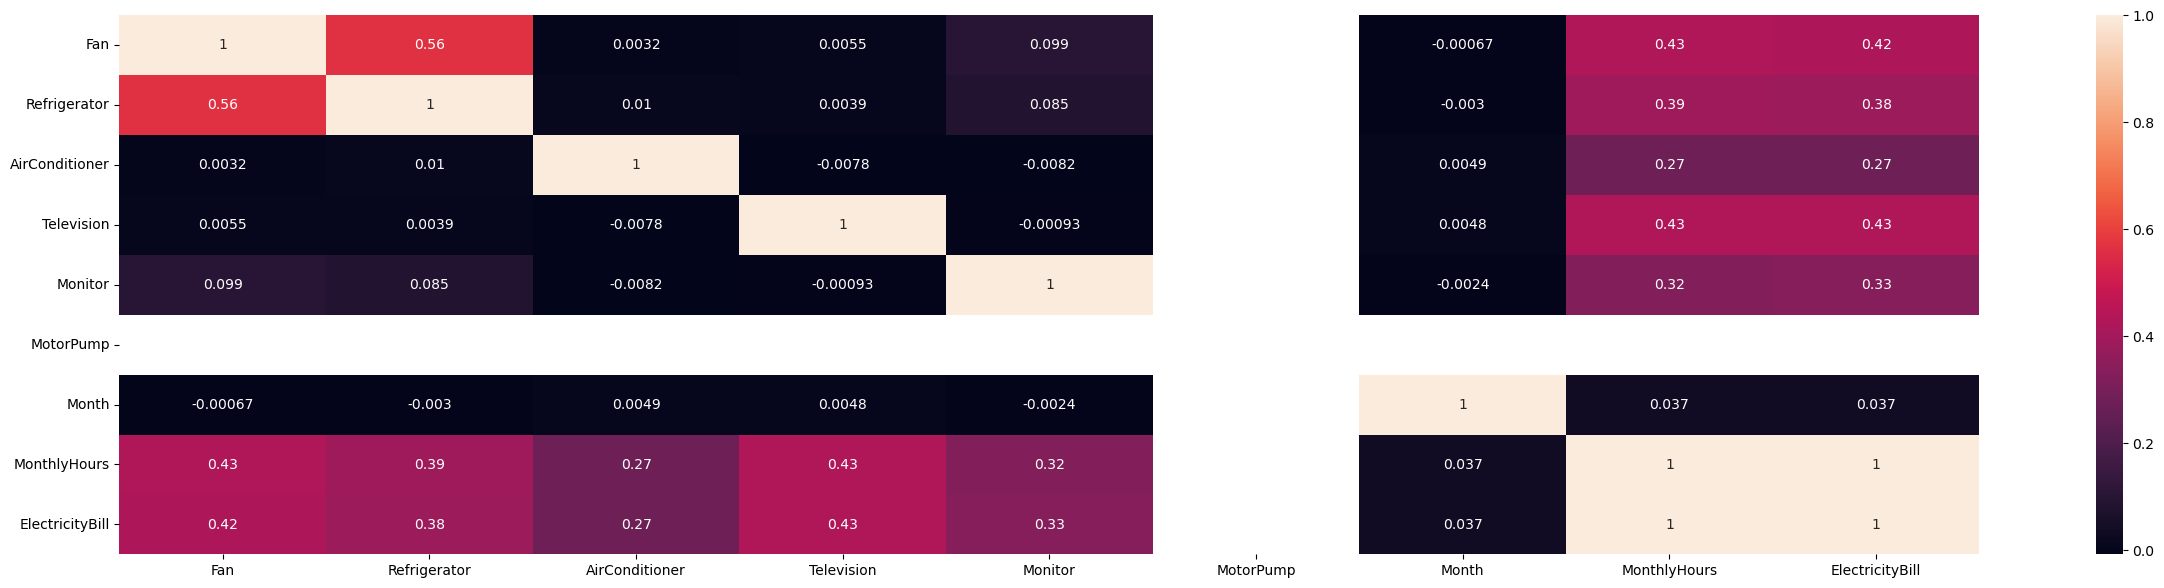

In [73]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot =True)
plt.rcParams['figure.figsize']=(30,7)
plt.show()

In [96]:
df.transpose()

,0,1,2,3,4,5,6,7,8,9,...,45335,45336,45337,45338,45339,45340,45341,45342,45343,45344
Fan,16,19,7,7,11,13,23,22,8,10,...,23,20,8,13,9,18,23,22,8,8
Refrigerator,23.00,22.00,20.00,22.00,23.00,22.00,22.00,23.00,20.00,23.00,...,22.00,23.00,17.00,22.00,17.00,22.00,23.00,22.00,21.00,17.00
AirConditioner,2.00,2.00,2.00,3.00,2.00,0.00,3.00,0.00,2.00,0.00,...,3.00,3.00,1.00,1.00,1.00,3.00,2.00,2.00,2.00,2.00
Television,6.00,3.00,6.00,21.00,11.00,18.00,20.00,21.00,8.00,18.00,...,8.00,16.00,6.00,4.00,21.00,22.00,6.00,20.00,22.00,4.00
Monitor,1.00,1.00,7.00,1.00,1.00,1.00,12.00,1.00,1.00,7.00,...,12.00,1.00,7.00,1.00,1.00,1.00,12.00,1.00,7.00,1.00
MotorPump,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Month,10,5,7,6,2,6,5,12,8,1,...,7,6,11,8,9,9,2,1,12,1
City,Hyderabad,Sargodha,Abbottabad,Sialkot,Sialkot,Gwadar,Lahore,Lahore,Lahore,Sukkur,...,Rawalpindi,Faisalabad,Mirpur (AJK),Mirpur (AJK),Islamabad,Faisalabad,Lahore,Lahore,Gwadar,Islamabad
Company,Hyderabad Electric Supply Company (HESCO),Faisalabad Electric Supply Company (FESCO),Peshawar Electric Supply Company (PESCO),Gujranwala Electric Power Company (GEPCO),Gujranwala Electric Power Company (GEPCO),Quetta Electric Supply Company (QESCO),Lahore Electric Supply Company (LESCO),Lahore Electric Supply Company (LESCO),Lahore Electric Supply Company (LESCO),Sukkur Electric Power Company (SEPCO),...,Islamabad Electric Supply Company (IESCO),Faisalabad Electric Supply Company (FESCO),Islamabad Electric Supply Company (IESCO),Islamabad Electric Supply Company (IESCO),Islamabad Electric Supply Company (IESCO),Faisalabad Electric Supply Company (FESCO),Lahore Electric Supply Company (LESCO),Lahore Electric Supply Company (LESCO),Quetta Electric Supply Company (QESCO),Islamabad Electric Supply Company (IESCO)
MonthlyHours,384,488,416,475,457,471,755,492,546,578,...,545,621,475,276,412,764,572,609,748,427


In [91]:
df.groupby('City')['ElectricityBill'].agg(['mean'])

,mean
City,
Abbottabad,21861.01
Bahawalpur,21895.99
Faisalabad,21732.15
Gwadar,21857.26
Hyderabad,21747.58
Islamabad,22040.64
Karachi,21844.50
Lahore,21912.01
Mirpur (AJK),22027.03


In [94]:
df2=df.groupby('Month')['ElectricityBill'].mean()

<Axes: xlabel='Month'>

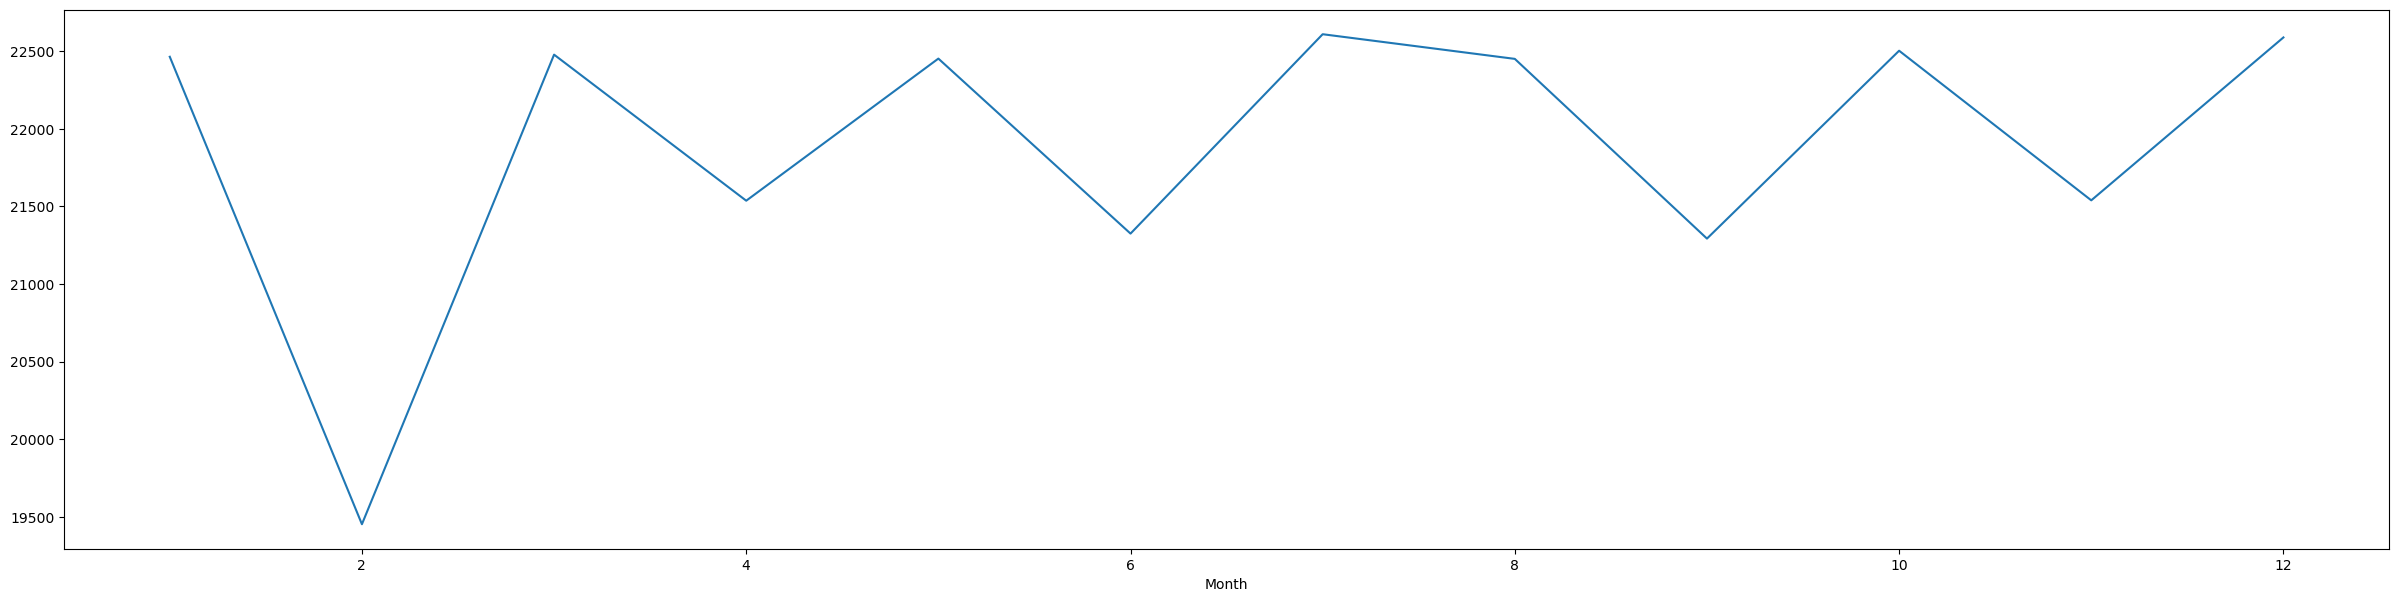

In [95]:
df2.plot()

<Axes: xlabel='City'>

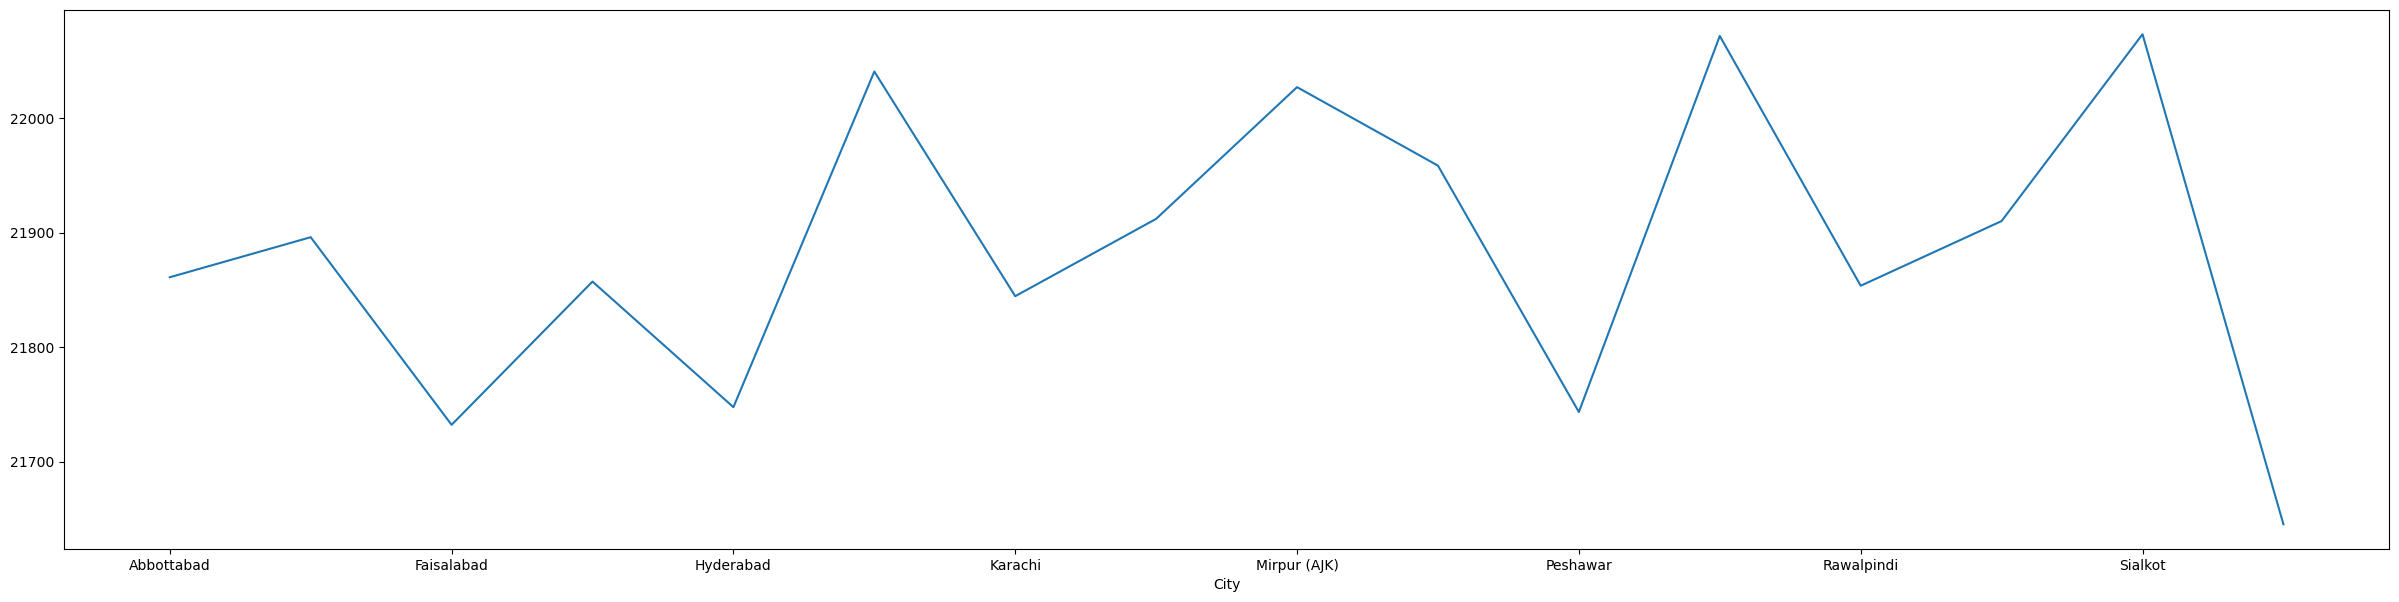

In [100]:
city_bill = df.groupby('City')['ElectricityBill'].mean()

city_bill.plot()

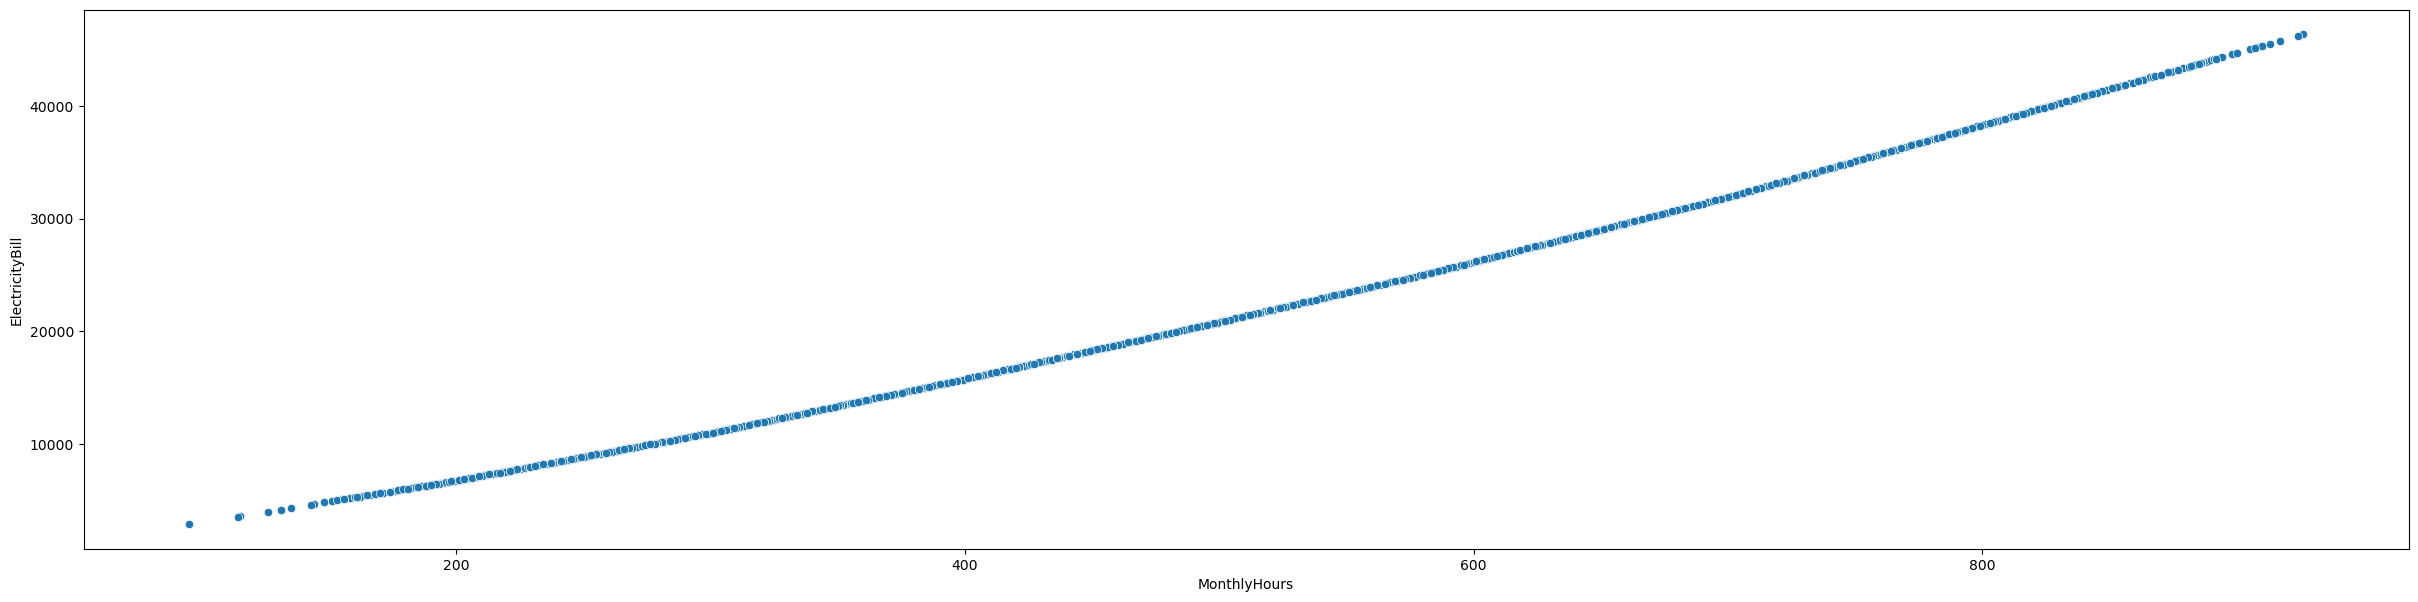

In [108]:
sns.scatterplot(data=df, x='MonthlyHours', y='ElectricityBill')
plt.show()

<Axes: >

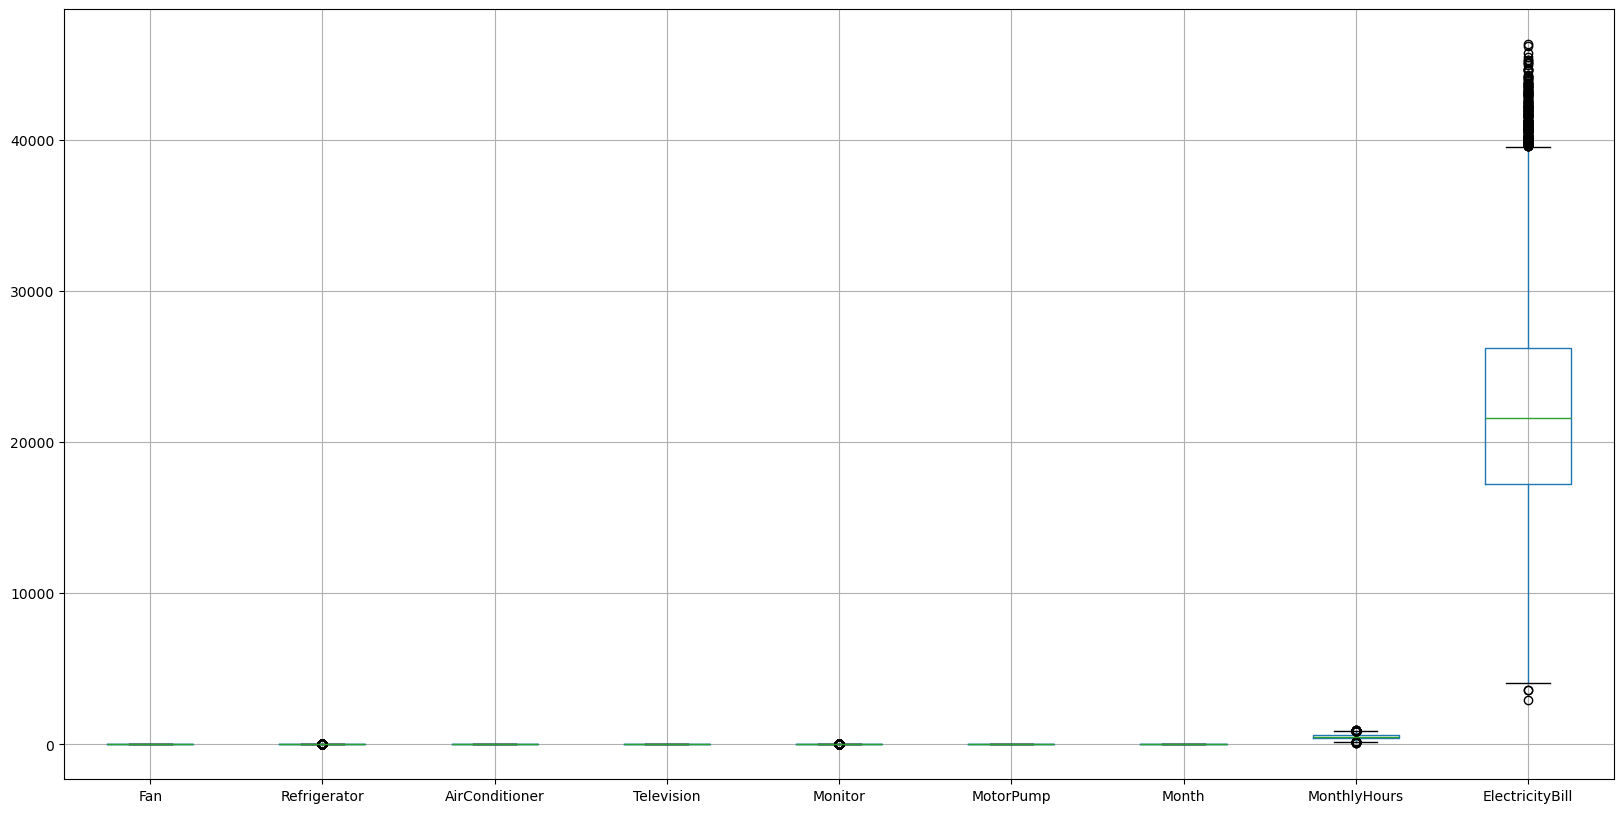

In [112]:
df.boxplot(figsize=(20,10))

In [119]:
df.select_dtypes(include='float')

,Refrigerator,AirConditioner,Television,Monitor,ElectricityBill
0,23.00,2.00,6.00,1.00,15022.05
1,22.00,2.00,3.00,1.00,20240.68
2,20.00,2.00,6.00,7.00,16598.51
3,22.00,3.00,21.00,1.00,19583.07
4,23.00,2.00,11.00,1.00,18672.52
...,...,...,...,...,...
45340,22.00,3.00,22.00,1.00,36003.43
45341,23.00,2.00,6.00,12.00,24609.33
45342,22.00,2.00,20.00,1.00,26671.13
45343,21.00,2.00,22.00,7.00,34981.10


In [122]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
45340    False
45341    False
45342    False
45343    False
45344    False
Length: 45345, dtype: bool

In [123]:
df.nunique()

Fan                 19
Refrigerator         7
AirConditioner       4
Television          20
Monitor              3
MotorPump            1
Month               12
City                16
Company             10
MonthlyHours       748
ElectricityBill    748
dtype: int64

In [124]:
num_cols = ['Fan','Refrigerator','AirConditioner','Television','Monitor','MonthlyHours','ElectricityBill']
print(df[num_cols].corr()['ElectricityBill'].sort_values(ascending=False))

ElectricityBill   1.00
MonthlyHours      1.00
Television        0.43
Fan               0.42
Refrigerator      0.38
Monitor           0.33
AirConditioner    0.27
Name: ElectricityBill, dtype: float64
